## Visualizing the action integral for a ball drop

The goal of this notebook is to conceptually illustrate why $\mathcal{L} = T - U$ gives correct equations of motion. We will consider the simple case where a ball is dropped straight down from a balcony.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import g
from sympy import Eq, Function, symbols, dsolve, Rational, init_printing
from sympy.calculus import euler_equations

# Pretty print of differential equation solutions
init_printing(use_latex='mathjax')

# Make readable plots
plt.rcParams.update({'font.size':16, 'axes.labelsize':16})

#### Problem setup

We will create visualizations for a real-life problem setup that uses physical units:

<ul>
    <li>Balcony height: $h = 30$ m </li>
    <li>Ball mass: $m = 0.1$ kg</li>
    <li>$g = 9.82$ m/s$^2$ imported from <tt>scipy.constants</tt></li>
</ul>

The ball is dropped straight downward. In order not to have to specify the coefficient of restitution, we will only consider the motion before the first bounce.

#### Newtonian formulation

<ul>
    <li>$y(t) = h - \frac{1}{2} \, g \, t^2$</li>
    <li>$v(t) = \dot{y}(t) = -g \, t$</li>
    <li>$U(t) = m \, g \, y(t)$</li>
    <li>$T(t) = \frac{1}{2} \, m \, v(t)^2$</li>
</ul>

#### Lagrangian formulation

<ul>
    <li>Find equations of motion using Euler-Lagrange equation: $\frac{\partial \mathcal{L}}{\partial y} - \frac{d}{dt} \left( \frac{\partial \mathcal{L}}{\partial \dot{y}} \right) = 0$</li>
    <li>Solve for $y(t)$ using $\mathcal{L} = T - U$</li>
</ul>

#### Visualization 1

Using Newtonian formulation, divide total ball drop time into small intervals $\delta t$. Make a scatter plot of $y(t)$ and $\dot{y}(t)$ with one dot for each time interval. Dots are color-coded by the time interval's contribution to the action integral: $\delta S = \mathcal{L}(t) \, \delta t$.

In [2]:
# Balcony height in meters
h = 30

# Ball mass in kg
m = 0.1

# Find total ball drop time
total_time = np.sqrt(2 * h / g)

# Small time intervals delta t are 1/30 of total time
N_intervals = 30
delta_t = total_time / N_intervals

# Time points for visualization
t = np.linspace(0, total_time, num=N_intervals, endpoint=True)

In [3]:
# Calculate position, velocity, and energies from Newtonian formulation
y = h - 0.5*g * t**2
v = -g * t
kinetic = 0.5*m * v**2
potential = m * g * y

In [4]:
# Calculate time-evolving Lagrangian and delta S in each time interval
L = kinetic - potential
delta_S = L * delta_t

In [5]:
# Negative contributions to action integral
negative_delta_S = np.where(delta_S < 0)[0]
threshold = t[negative_delta_S[-1]]

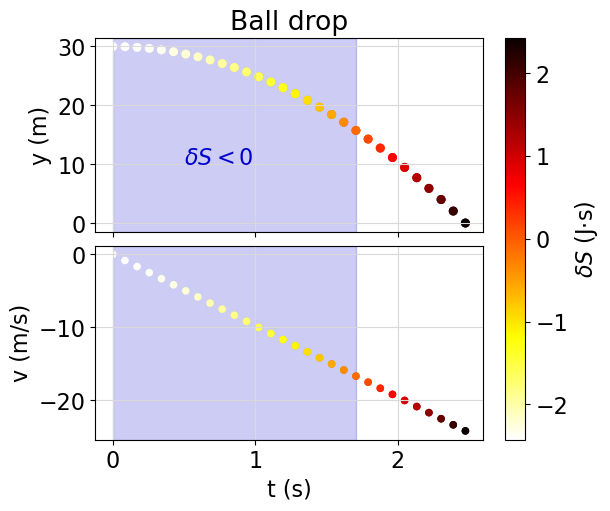

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(6,5), sharex=True, layout='compressed')

csp1 = axs[0].scatter(t, y, c=delta_S, cmap='hot_r', s=30)
axs[0].axvspan(0, threshold, color='mediumblue', alpha=0.2)
axs[0].scatter(t, y, c=delta_S, cmap='hot_r', s=30)
axs[0].set_ylabel('y (m)')
axs[0].grid(color='0.85')
axs[0].set_title(r"Ball drop")
axs[0].text(0.5, 10, r"$\delta S < 0$", color='mediumblue')

axs[1].scatter(t, v, c=delta_S, cmap='hot_r', s=20)
axs[1].axvspan(0, threshold, color='mediumblue', alpha=0.2)
axs[1].scatter(t, v, c=delta_S, cmap='hot_r', s=20)
axs[1].set_ylabel('v (m/s)')
axs[1].set_xlabel('t (s)')
axs[1].grid(color='0.85')

cbar = fig.colorbar(csp1, ax=axs, label=r"$\delta S$ (J$\cdot$s)", fraction=0.1)

In the blue shaded region of each plot, the action integral contribution $\delta S$ from each time interval $\delta t$ is negative. The Lagrangian formulation forces the ball to spend as few time intervals in regions of the $(y, \dot{y})$ parameter space with high $\mathcal{L}$ as much as possible. Although positive $\mathcal{L}$ and positive $\delta S$ can't be avoided if the ball is going to eventually hit the ground, it is confined to $\sim 1/3$ of the ball's drop time.

#### Visualization 2

Here we examine the ball's trajectory through $(y, \dot{y})$ space color-coded by $\delta S$, with region of $\delta S < 0$ shaded in blue and $\delta S > 0$ in pink. Parts of $(y, \dot{y})$ parameter space that are not on this particular ball's trajectory could belong to a ball with a different mass and/or dropped from a different height.

In [7]:
ygr, vgr = np.meshgrid(y, v)
Tgr = 0.5 * m * vgr**2
Ugr = m * g * ygr
Lgr = Tgr - Ugr

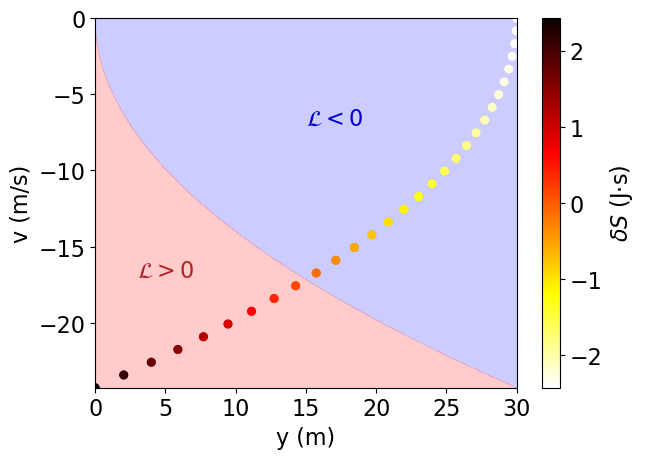

In [8]:
fig, ax = plt.subplots(1, 1)

csp2 = ax.scatter(y, v, c=delta_S, cmap='hot_r', s=30)
ax.contourf(ygr, vgr, Lgr, levels=[-30, 0, 30], cmap='bwr', alpha=0.4)
ax.scatter(y, v, c=delta_S, cmap='hot_r', s=30)
ax.set_xlabel('y (m)')
ax.set_ylabel('v (m/s)')
ax.text(15, -7, r"$\mathcal{L} < 0$", color='mediumblue')
ax.text(3, -17, r"$\mathcal{L} > 0$", color='firebrick')

cbar = fig.colorbar(csp2, ax=ax, label=r"$\delta S$ (J$\cdot$s)", fraction=0.1)

#### Recovering $y(t)$ using <tt>sympy</tt>

Here we will let <tt>sympy</tt> figure out the position function $y(t)$ starting from $\mathcal{L} = T - U = \frac{1}{2} m \dot{y}^2 - m g y$. First we will define the Lagrangian and use <tt>euler_equations()</tt> to find the Euler-Lagrange equation.

In [9]:
t = symbols('t')
m, g, h = symbols('m g h', real=True, constant=True)
y = Function('y')(t)
ydot = y.diff(t)
L = Rational('0.5')*m * ydot**2 - m*g * y
EL = euler_equations(L, y, t)[0]

In [10]:
EL

          2           
         d            
-g⋅m - m⋅───(y(t)) = 0
           2          
         dt           

<tt>euler_equations()</tt> successfully recovered $F = ma$, now solve for $y(t)$ with initial conditions $h = 30$ m and $\dot{y}(0) = 0$.

In [11]:
dsolve(EL, y, ics={ydot.subs(t, 0): 0, y.subs(t, 0): 30})

            2     
         g⋅t      
y(t) = - ──── + 30
          2       